# Scientific Analysis of Cognitive Readiness
## Webcam-Based Cognitive Readiness Assessment

---

### Study Context

**Cognitive readiness** refers to an individual's capacity to process information, sustain attention, and respond appropriately in a given context. Rooted in cognitive science and human factors engineering, this concept is particularly relevant in education, occupational health, and human performance research.

### Notebook Objective

This notebook provides a **rigorous statistical analysis** of data collected through a webcam-based cognitive assessment system using **eye-tracking technology**. The analysis covers:

1. **Descriptive exploration** — Score distributions and central tendencies
2. **Correlational analysis** — Relationships between cognitive dimensions (Pearson, Spearman)
3. **Between-group comparisons** — Demographic differences (gender, age, occupation)
4. **Hypothesis testing** — ANOVA, Kruskal-Wallis, Mann-Whitney U
5. **Predictive modeling** — Multiple linear regression with diagnostics

### Measured Variables

| Dimension | Description |
|---|---|
| **Global Score** | Composite cognitive readiness score (0–100) |
| **Visual Processing** | Ability to process visual information |
| **Response Speed** | Reaction speed to stimuli |
| **Attention Stability** | Sustained attention over time |
| **Pattern Recognition** | Ability to identify patterns and structures |
| **Gaze Count** | Total number of recorded gaze points |
| **Blink Count** | Number of detected blinks |
| **Duration** | Assessment session length (minutes) |

### Data Acquisition Method

Data is collected via a **webcam-based eye calibration system** (9-point grid). Raw metrics (fixations, saccades, blinks, gaze entropy) are transformed into normalized scores (0–100) by proprietary algorithms.

---

In [3]:
# =============================================================================
# Cognitive Readiness Assessment — Scientific Analysis Notebook
# =============================================================================
# Dataset: all_cognitive_readiness_results_2026-03-17
# Objective: Explore, correlate, and visualize webcam-based cognitive metrics
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway, kruskal, mannwhitneyu, shapiro
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
# --- 1. Data Loading ---
CSV_PATH = "/Users/kiki/Downloads/all_cognitive_readiness_results_2026-03-17 (1).csv"
df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')

# Drop the heavy JSON column — not needed for statistical analysis
if 'row_json' in df.columns:
    df.drop(columns=['row_json'], inplace=True)
if 'ai_analysis_text' in df.columns:
    df.drop(columns=['ai_analysis_text'], inplace=True)

print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(3)

Dataset: 63 rows × 39 columns


,id,recorded_at,student_id,full_name,first_name,last_name,email,age_range,gender,occupation_status,...,attention_stability,pattern_recognition,gaze_count,blink_count,duration,feedback_ease_of_use,feedback_report_value,feedback_submitted_at,ai_analysis_provider,ai_analysis_generated_at
0,104,2026-03-17T10:31:16.726Z,14,Moulay Hamza Kanzi Belghiti,NaN,NaN,mhkbelghiti@gmail.com,25-34 years,Male,Self-employed/Entrepreneur,...,60,65,16056,51,3,NaN,NaN,NaN,NaN,NaN
1,102,2026-03-17T05:38:04.874Z,11,safae,NaN,NaN,safae.menani8@gmail.com,18-24 years,Prefer not to say,Student (Undergraduate),...,50,33,3209,21,3,NaN,NaN,NaN,Groq,2026-03-17T05:38:16.503Z
2,101,2026-03-16T17:48:46.252Z,42,Mohamed Merrouch,NaN,NaN,m.merrouch99@gmail.com,25-34 years,Male,Engineer/Technical Professional,...,0,34,10891,0,3,3.0,4.0,2026-03-16T17:50:35.802Z,Groq,2026-03-16T17:49:24.233Z


In [5]:
# --- 2. Data Overview ---
print("=== Data Types ===")
print(df.dtypes.to_string())
print("\n=== Missing Values (top columns) ===")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).to_string())

=== Data Types ===
id                                  int64
recorded_at                        object
student_id                          int64
full_name                          object
first_name                         object
last_name                          object
email                              object
age_range                          object
gender                             object
occupation_status                  object
job_title                          object
first_time_fasting                 object
diagnosed_conditions               object
medication_affecting_alertness     object
medication_details                float64
webcam_calibration_experience      object
student_device_used                object
device_type                       float64
device_used                        object
screen_width                      float64
screen_height                     float64
viewport_width                    float64
viewport_height                   float64
device_pixel_ra

In [6]:
# --- 3. Define Key Variables ---
# Cognitive scores (dependent variables)
SCORE_COLS = ['global_score', 'visual_processing', 'response_speed',
              'attention_stability', 'pattern_recognition']

# Eye-tracking raw metrics
EYE_COLS = ['gaze_count', 'blink_count', 'duration']

# All numeric columns of interest
NUMERIC_COLS = SCORE_COLS + EYE_COLS

# Demographic / categorical columns
CAT_COLS = ['age_range', 'gender', 'occupation_status', 'device_used',
            'first_time_fasting', 'diagnosed_conditions']

# Clean: ensure numeric types
for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove rows where global_score is missing (no valid assessment)
n_before = len(df)
df = df.dropna(subset=['global_score'])
print(f"Rows kept: {len(df)} / {n_before} (dropped {n_before - len(df)} with missing global_score)")

Rows kept: 63 / 63 (dropped 0 with missing global_score)


## 4. Descriptive Statistics

Descriptive statistics are the **essential first step** of any data analysis. They summarize the main characteristics of a dataset without making prior assumptions.

### Key Indicators

| Indicator | Formula | Interpretation |
|---|---|---|
| **Mean** ($\bar{x}$) | $\frac{1}{n}\sum x_i$ | Central tendency — sensitive to extreme values |
| **Standard Deviation** ($s$) | $\sqrt{\frac{1}{n-1}\sum(x_i - \bar{x})^2}$ | Spread around the mean |
| **Median** | Central value | Central tendency — robust to outliers |
| **Skewness** | $\frac{m_3}{s^3}$ | > 0: right tail; < 0: left tail |
| **Kurtosis** | $\frac{m_4}{s^4} - 3$ | > 0: leptokurtic (peaked); < 0: platykurtic (flat) |

> **Interpretation:** A skewness close to 0 and kurtosis close to 0 suggest an approximately normal distribution — an important condition for the parametric tests used later.

In [7]:
# --- 4a. Descriptive Statistics for Cognitive Scores ---
desc = df[SCORE_COLS].describe().T
desc['median'] = df[SCORE_COLS].median()
desc['skew'] = df[SCORE_COLS].skew()
desc['kurtosis'] = df[SCORE_COLS].kurtosis()
desc = desc[['count', 'mean', 'std', 'median', 'min', '25%', '75%', 'max', 'skew', 'kurtosis']]
desc.round(2)

,count,mean,std,median,min,25%,75%,max,skew,kurtosis
global_score,63.0,40.35,17.76,43.0,10.0,27.0,48.5,95.0,0.82,1.47
visual_processing,63.0,20.38,19.96,20.0,0.0,0.0,33.5,76.0,0.67,-0.18
response_speed,63.0,23.56,20.97,20.0,0.0,0.0,40.5,79.0,0.40,-0.77
attention_stability,63.0,21.49,25.83,0.0,0.0,0.0,47.0,70.0,0.57,-1.37
pattern_recognition,63.0,35.62,22.57,36.0,0.0,22.0,54.0,79.0,-0.26,-0.76


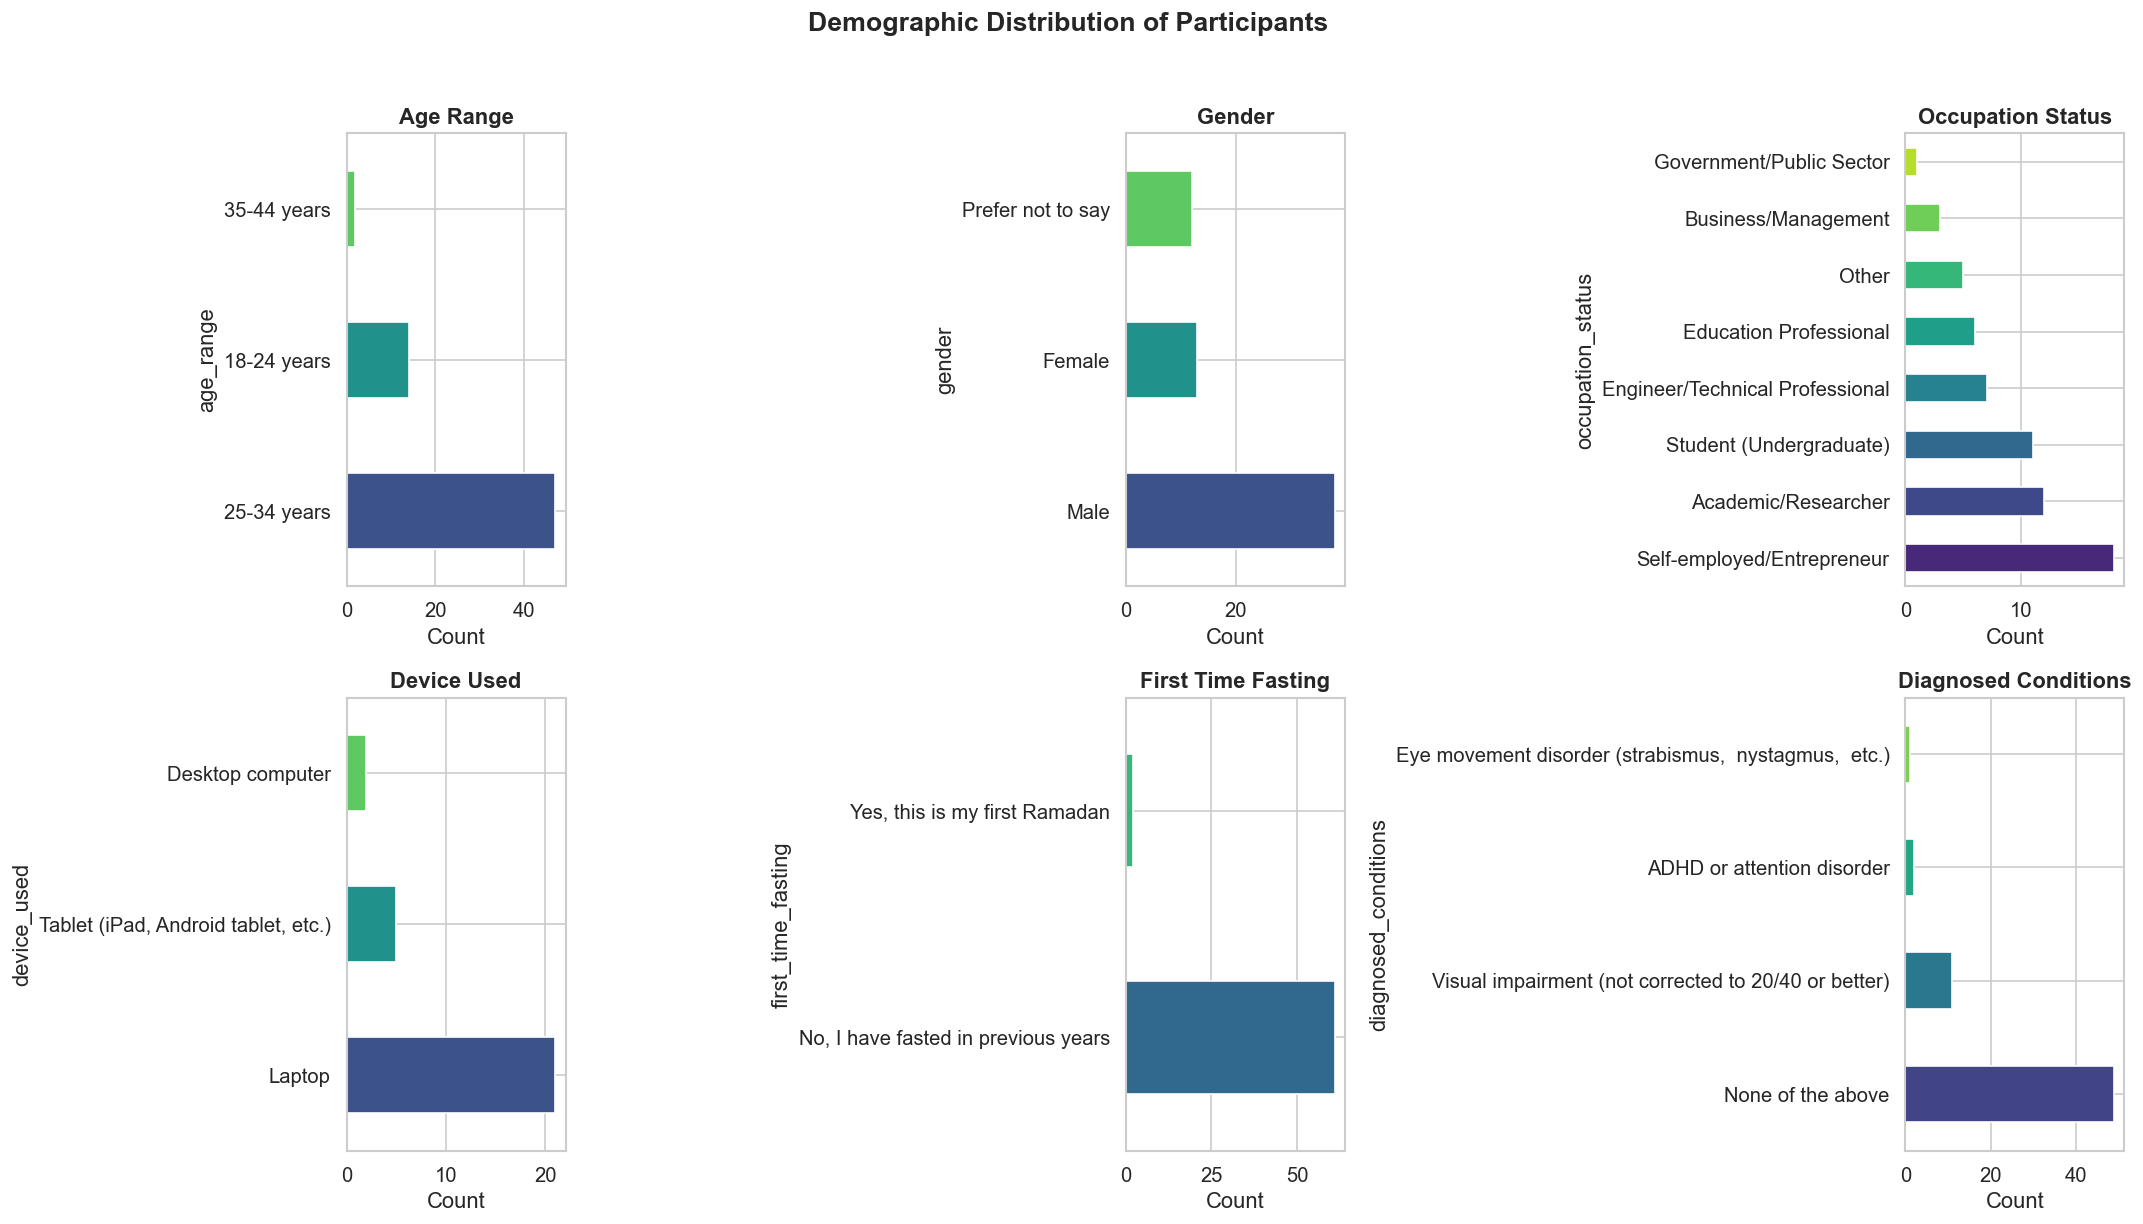

In [8]:
# --- 4b. Demographic Breakdown ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flat, CAT_COLS):
    counts = df[col].value_counts().head(8)
    counts.plot.barh(ax=ax, color=sns.color_palette("viridis", len(counts)))
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Count')

plt.suptitle("Demographic Distribution of Participants", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Score Distributions and Normality Tests

### Why Study Distributions?

The shape of a variable's distribution determines the **choice of statistical tests**:

- **Normal distribution** (Gaussian) → **Parametric** tests (t-test, ANOVA, Pearson): more powerful
- **Non-normal distribution** → **Non-parametric** tests (Mann-Whitney, Kruskal-Wallis, Spearman): more robust

### Diagnostic Tools

1. **Histogram + KDE** (*Kernel Density Estimation*): A non-parametric estimate of the probability density function. Helps visualize the overall shape of the distribution.

2. **Boxplot** (box-and-whisker diagram): A 5-number summary — minimum, Q1, median, Q3, maximum. Points beyond 1.5 × IQR are considered **outliers**.

3. **Shapiro-Wilk Test**: A formal hypothesis test.
   - $H_0$: The data follows a normal distribution
   - $H_1$: The data does not follow a normal distribution
   - If $p < 0.05$ → reject $H_0$ → distribution is **non-normal**
   
> **Caution:** The Shapiro-Wilk test is highly sensitive to sample size. For $n > 50$, very slight deviations from normality can yield a significant result. It is therefore recommended to **combine** the formal test with visual inspection (Q-Q plot, histogram).

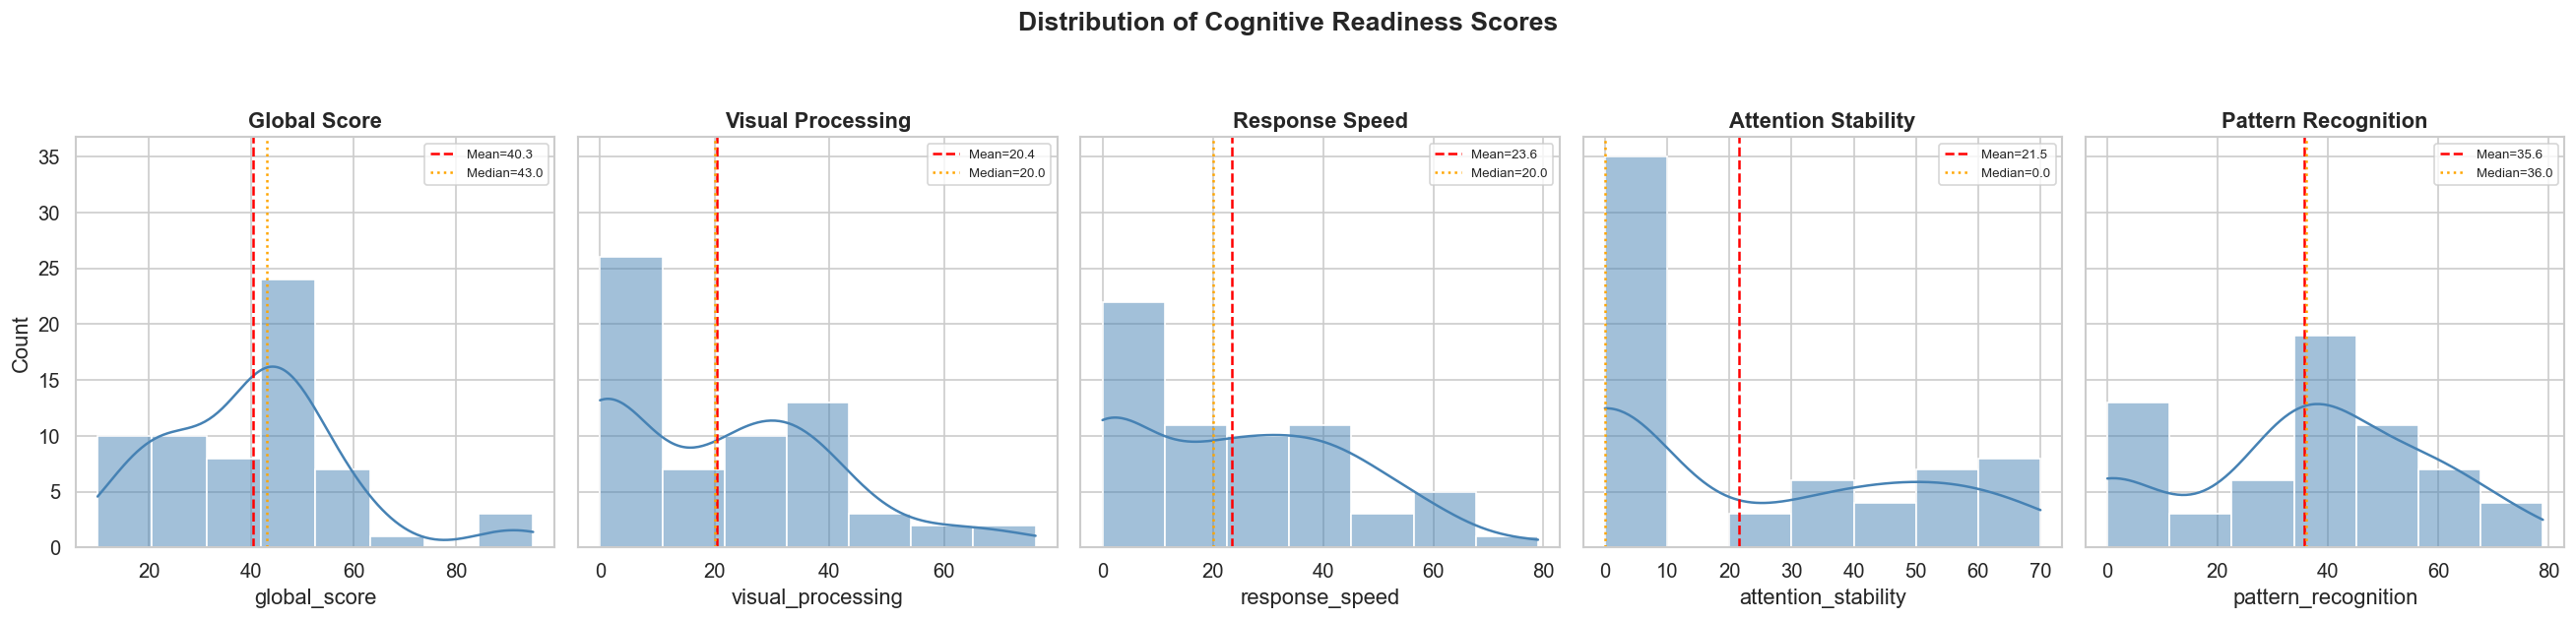

In [9]:
# --- 5a. Histograms + KDE for each cognitive score ---
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

for ax, col in zip(axes, SCORE_COLS):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue', edgecolor='white')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle=':', label=f'Median={df[col].median():.1f}')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle("Distribution of Cognitive Readiness Scores", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

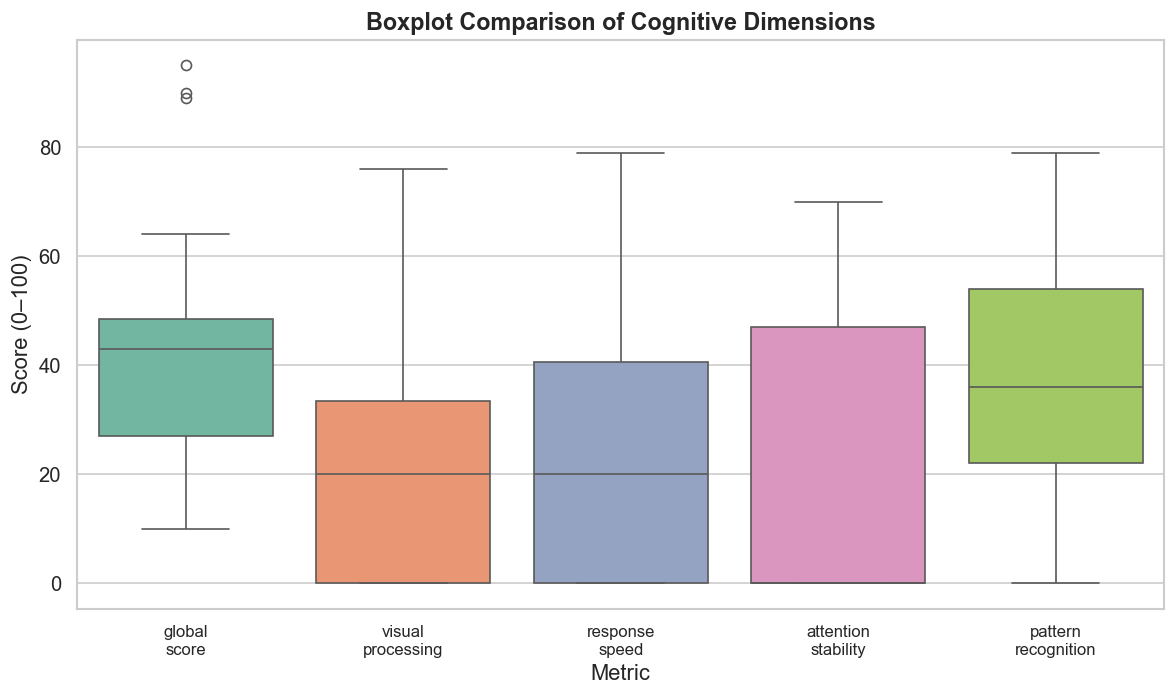

In [10]:
# --- 5b. Boxplots for all scores side by side ---
fig, ax = plt.subplots(figsize=(10, 6))
df_melted = df[SCORE_COLS].melt(var_name='Metric', value_name='Score')
sns.boxplot(data=df_melted, x='Metric', y='Score', palette='Set2', ax=ax)
ax.set_xticklabels([c.replace('_', '\n') for c in SCORE_COLS], fontsize=10)
ax.set_title("Boxplot Comparison of Cognitive Dimensions", fontsize=14, fontweight='bold')
ax.set_ylabel("Score (0–100)")
plt.tight_layout()
plt.show()

In [11]:
# --- 5c. Normality Tests (Shapiro-Wilk) ---
print("=== Shapiro-Wilk Normality Tests ===")
print(f"{'Metric':<25} {'W-statistic':>12} {'p-value':>12} {'Normal?':>10}")
print("-" * 62)
for col in SCORE_COLS:
    data = df[col].dropna()
    if len(data) > 3:
        w_stat, p_val = shapiro(data.sample(min(len(data), 5000)))
        normal = "Yes" if p_val > 0.05 else "No"
        print(f"{col:<25} {w_stat:>12.4f} {p_val:>12.6f} {normal:>10}")

=== Shapiro-Wilk Normality Tests ===
Metric                     W-statistic      p-value    Normal?
--------------------------------------------------------------
global_score                    0.9319     0.001783         No
visual_processing               0.8722     0.000010         No
response_speed                  0.8996     0.000087         No
attention_stability             0.7584     0.000000         No
pattern_recognition             0.9219     0.000666         No


## 6. Correlation Analysis

### Theoretical Foundations

**Correlation** measures the strength and direction of the linear (or monotonic) association between two quantitative variables. It is a fundamental tool in psychometrics and cognitive science for evaluating the **convergent** and **discriminant validity** of a measurement instrument.

### Two Types of Correlation

| | **Pearson** ($r$) | **Spearman** ($\rho$) |
|---|---|---|
| **Assumption** | Linear relationship, bivariate normality | Monotonic relationship (not necessarily linear) |
| **Computation** | Normalized covariance | Pearson correlation on ranks |
| **Sensitivity** | Outliers, non-normality | Robust |
| **Use case** | Continuous, normally distributed data | Ordinal or non-normal data |

### Pearson Formula

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \cdot \sum(y_i - \bar{y})^2}}$$

### Interpreting Correlation Strength

| $|r|$ | Interpretation |
|---|---|
| 0.00 – 0.19 | Very weak |
| 0.20 – 0.39 | Weak |
| 0.40 – 0.59 | Moderate |
| 0.60 – 0.79 | Strong |
| 0.80 – 1.00 | Very strong |

### Statistical Significance

A correlation is **statistically significant** if the probability of observing such a value under $H_0$ (no correlation) is below the threshold $\alpha$:

- $* \quad p < 0.05$ — significant
- $** \quad p < 0.01$ — highly significant  
- $*** \quad p < 0.001$ — very highly significant

> **Important reminder:** Correlation $\neq$ Causation. A significant correlation between two variables does not imply that one causes the other. A **confounding third variable** may explain the observed association.

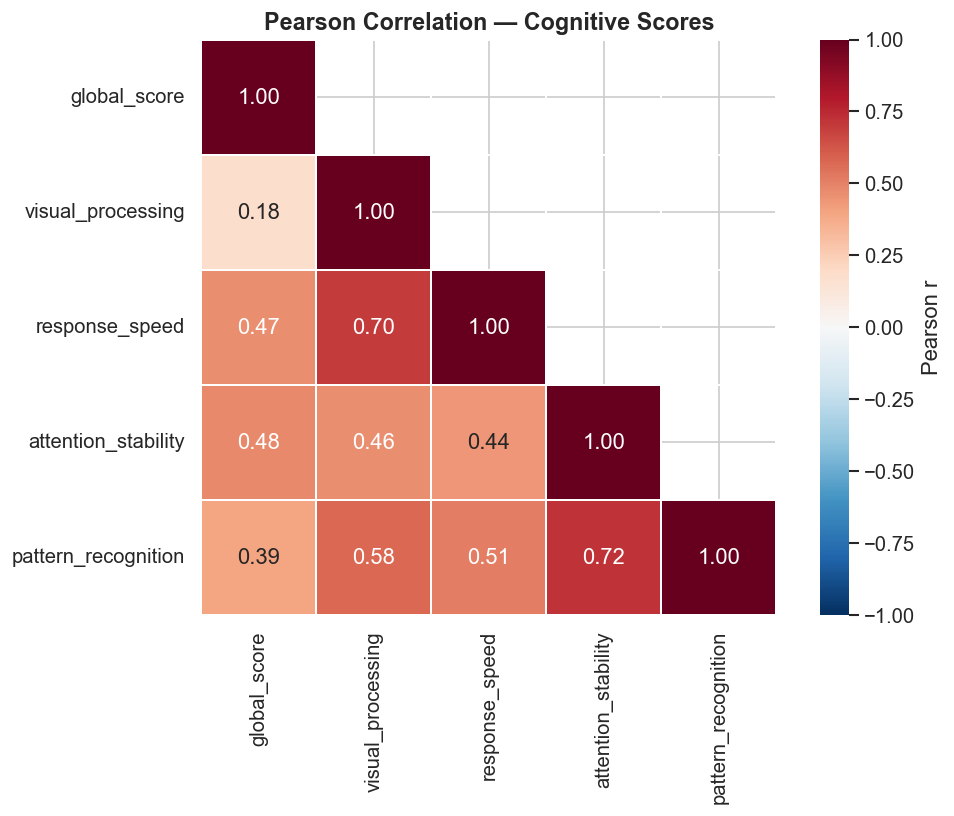

In [12]:
# --- 6a. Pearson Correlation Matrix (Cognitive Scores) ---
corr_pearson = df[SCORE_COLS].corr(method='pearson')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=1, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'label': 'Pearson r'})
ax.set_title("Pearson Correlation — Cognitive Scores", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6b. Spearman Correlation — Robust Alternative

Spearman's correlation is based on the **ranks** of observations rather than raw values. It is recommended when:
- Distributions are not normal (cf. section 5c)
- The relationship is monotonic but not strictly linear
- The sample contains extreme values

If Pearson and Spearman correlations are **similar**, this confirms the linearity of the relationship. If they **diverge**, the relationship is likely non-linear.

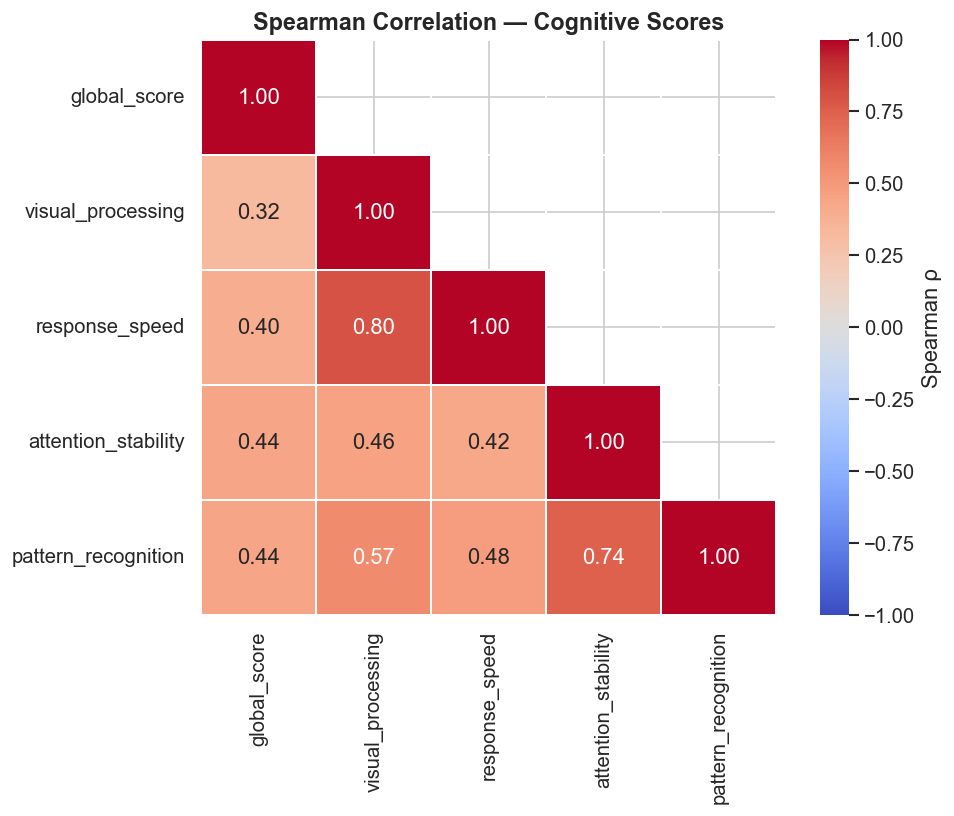

In [13]:
# --- 6b. Spearman Correlation Matrix (robust to non-normality) ---
corr_spearman = df[SCORE_COLS].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool), k=1)
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=1, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'label': 'Spearman ρ'})
ax.set_title("Spearman Correlation — Cognitive Scores", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6c. Detailed Table with P-Values

The **p-value** represents the probability of observing a correlation at least as extreme under the null hypothesis ($H_0: \rho = 0$). A conventional threshold of $\alpha = 0.05$ is used, with Bonferroni correction recommended for multiple comparisons.

In [14]:
# --- 6c. Correlation with p-values (detailed table) ---
from itertools import combinations

results = []
for col1, col2 in combinations(SCORE_COLS, 2):
    valid = df[[col1, col2]].dropna()
    if len(valid) > 3:
        r_p, p_p = pearsonr(valid[col1], valid[col2])
        r_s, p_s = spearmanr(valid[col1], valid[col2])
        results.append({
            'Variable 1': col1,
            'Variable 2': col2,
            'N': len(valid),
            'Pearson r': round(r_p, 4),
            'Pearson p': round(p_p, 6),
            'Spearman ρ': round(r_s, 4),
            'Spearman p': round(p_s, 6),
            'Significant (α=0.05)': '***' if p_p < 0.001 else '**' if p_p < 0.01 else '*' if p_p < 0.05 else 'ns'
        })

corr_table = pd.DataFrame(results)
corr_table

,Variable 1,Variable 2,N,Pearson r,Pearson p,Spearman ρ,Spearman p,Significant (α=0.05)
0,global_score,visual_processing,63,0.1785,0.161699,0.3170,0.011370,ns
1,global_score,response_speed,63,0.4676,0.000111,0.3971,0.001271,***
2,global_score,attention_stability,63,0.4787,0.000072,0.4414,0.000293,***
3,global_score,pattern_recognition,63,0.3932,0.001432,0.4377,0.000334,**
4,visual_processing,response_speed,63,0.7008,0.000000,0.7987,0.000000,***
5,visual_processing,attention_stability,63,0.4635,0.000131,0.4602,0.000148,***
6,visual_processing,pattern_recognition,63,0.5767,0.000001,0.5686,0.000001,***
7,response_speed,attention_stability,63,0.4428,0.000279,0.4240,0.000535,***
8,response_speed,pattern_recognition,63,0.5091,0.000020,0.4775,0.000076,***
9,attention_stability,pattern_recognition,63,0.7195,0.000000,0.7443,0.000000,***


### 6d. Extended Matrix: Cognitive Scores + Eye-Tracking Metrics

This matrix integrates **raw eye-tracking metrics** (gaze_count, blink_count, duration) with cognitive scores. The goal is to identify whether physiological eye-tracking indicators are associated with the measured cognitive performance.

> **Hypothesis:** A higher `gaze_count` (more samples) should be associated with more reliable scores. `blink_count` may reflect fatigue or cognitive load.

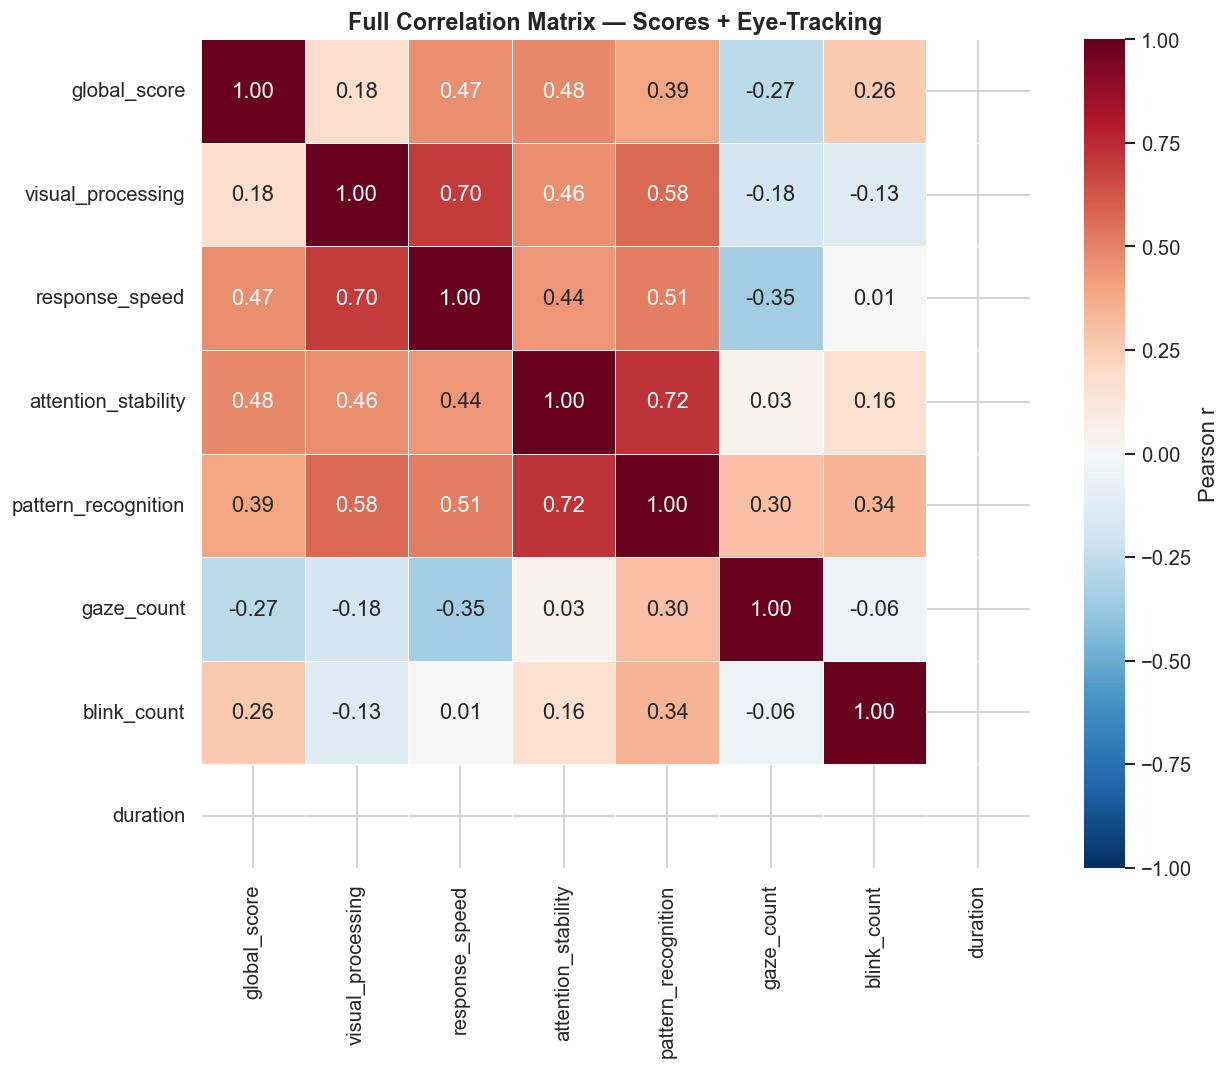

In [15]:
# --- 6d. Extended Correlation: Scores + Eye-Tracking Metrics ---
ALL_NUMERIC = SCORE_COLS + EYE_COLS
corr_all = df[ALL_NUMERIC].corr(method='pearson')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson r'})
ax.set_title("Full Correlation Matrix — Scores + Eye-Tracking", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Bivariate Visualization: Scatter Plots & Pairplots

### Purpose of Scatter Plots

The **scatter plot** is the essential visual complement to numerical correlation. It allows you to:

- **Verify linearity** of the relationship (Pearson assumption)
- **Detect influential outliers**
- **Identify subgroups** or non-linear patterns
- **Visualize regression** via the least squares line

### Pairplot

The **pairplot** (scatter plot matrix) displays all bivariate combinations of a set of variables. The diagonal shows the univariate distribution (KDE). It is a powerful exploratory tool for quickly detecting relationships and anomalies.

### Regression Line

The red line in the scatter plots represents the **simple linear model**: $y = \beta_0 + \beta_1 x$. Its slope ($\beta_1$) and the Pearson $r$ coefficient (displayed in the title) quantify the relationship.

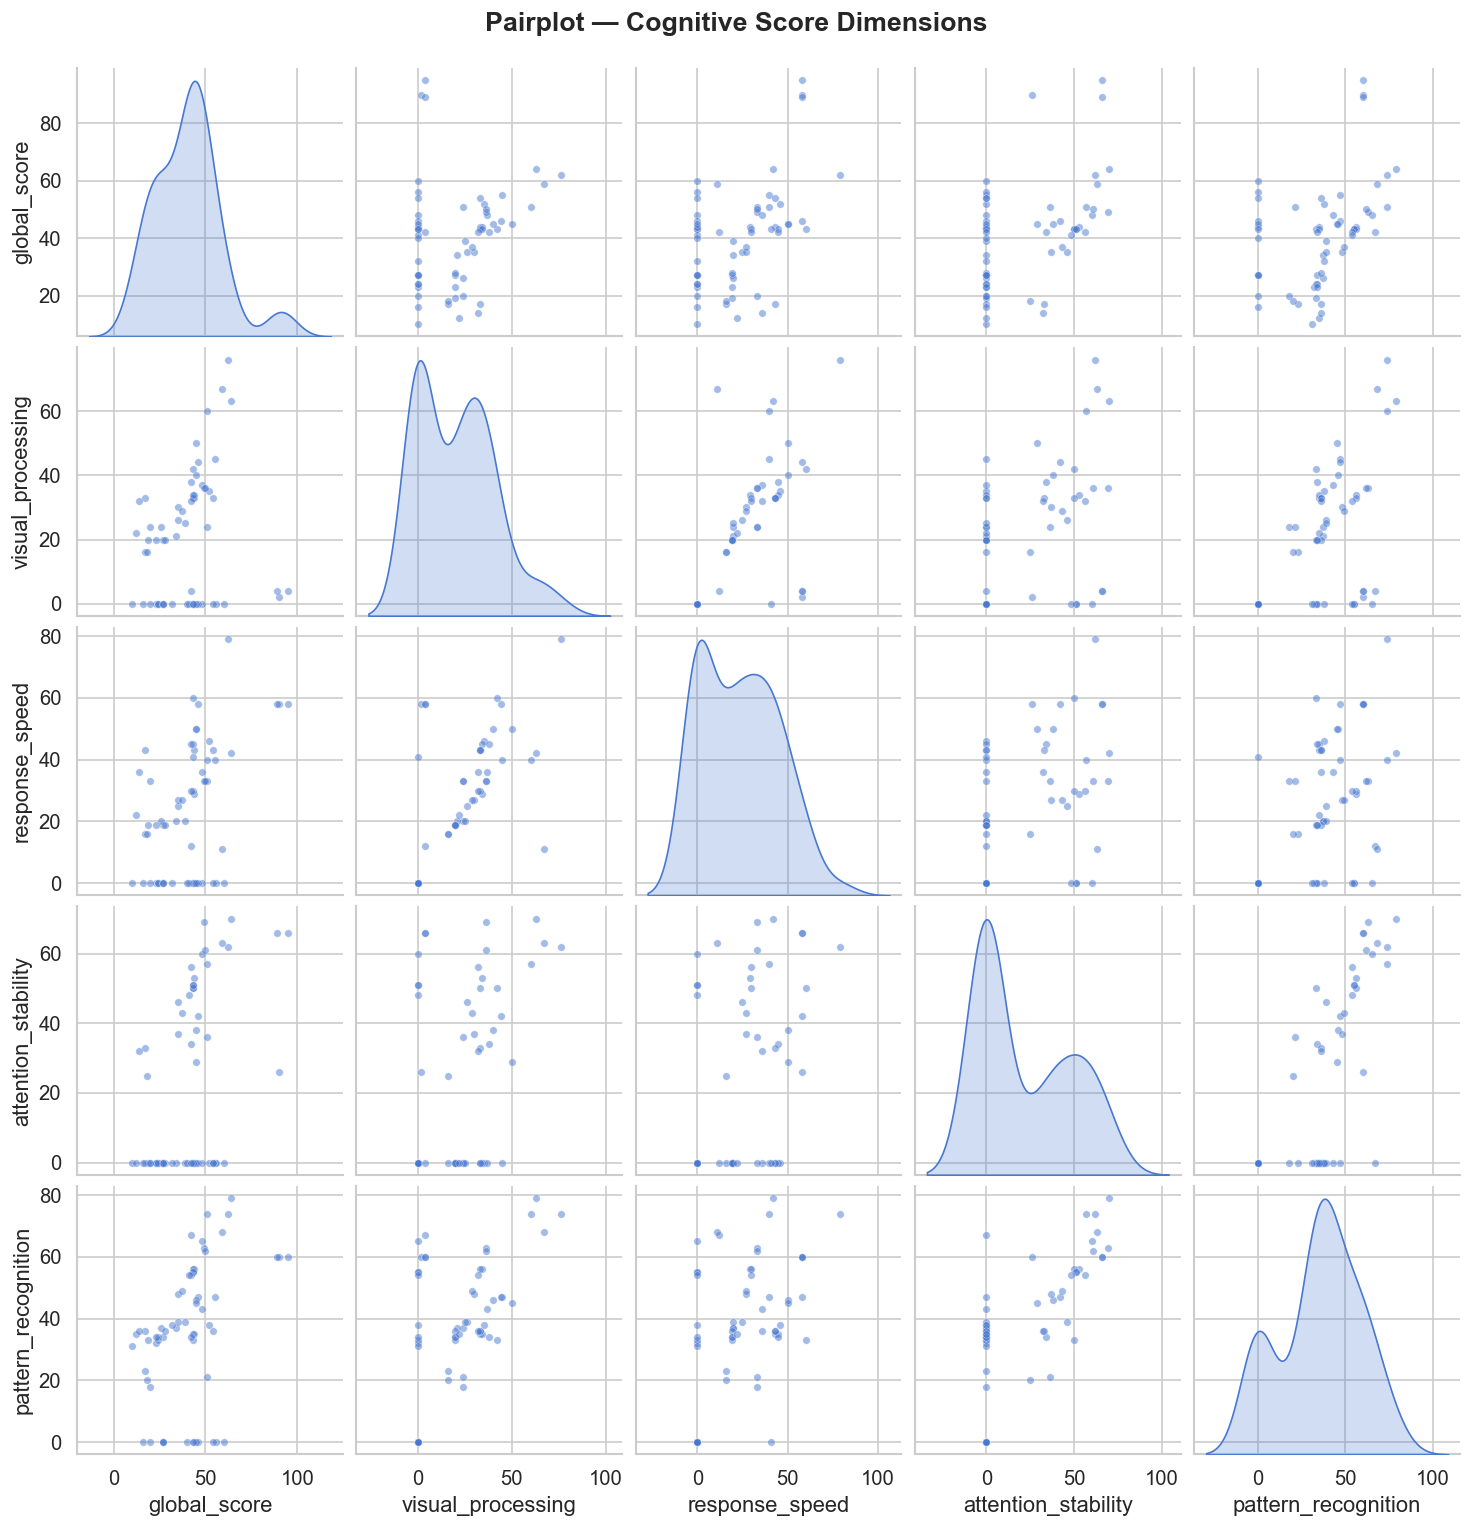

In [16]:
# --- 7a. Pairplot of Cognitive Scores ---
g = sns.pairplot(df[SCORE_COLS].dropna(), diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 20, 'edgecolor': 'white'},
                 diag_kws={'fill': True})
g.figure.suptitle("Pairplot — Cognitive Score Dimensions", fontsize=16, fontweight='bold', y=1.02)
plt.show()

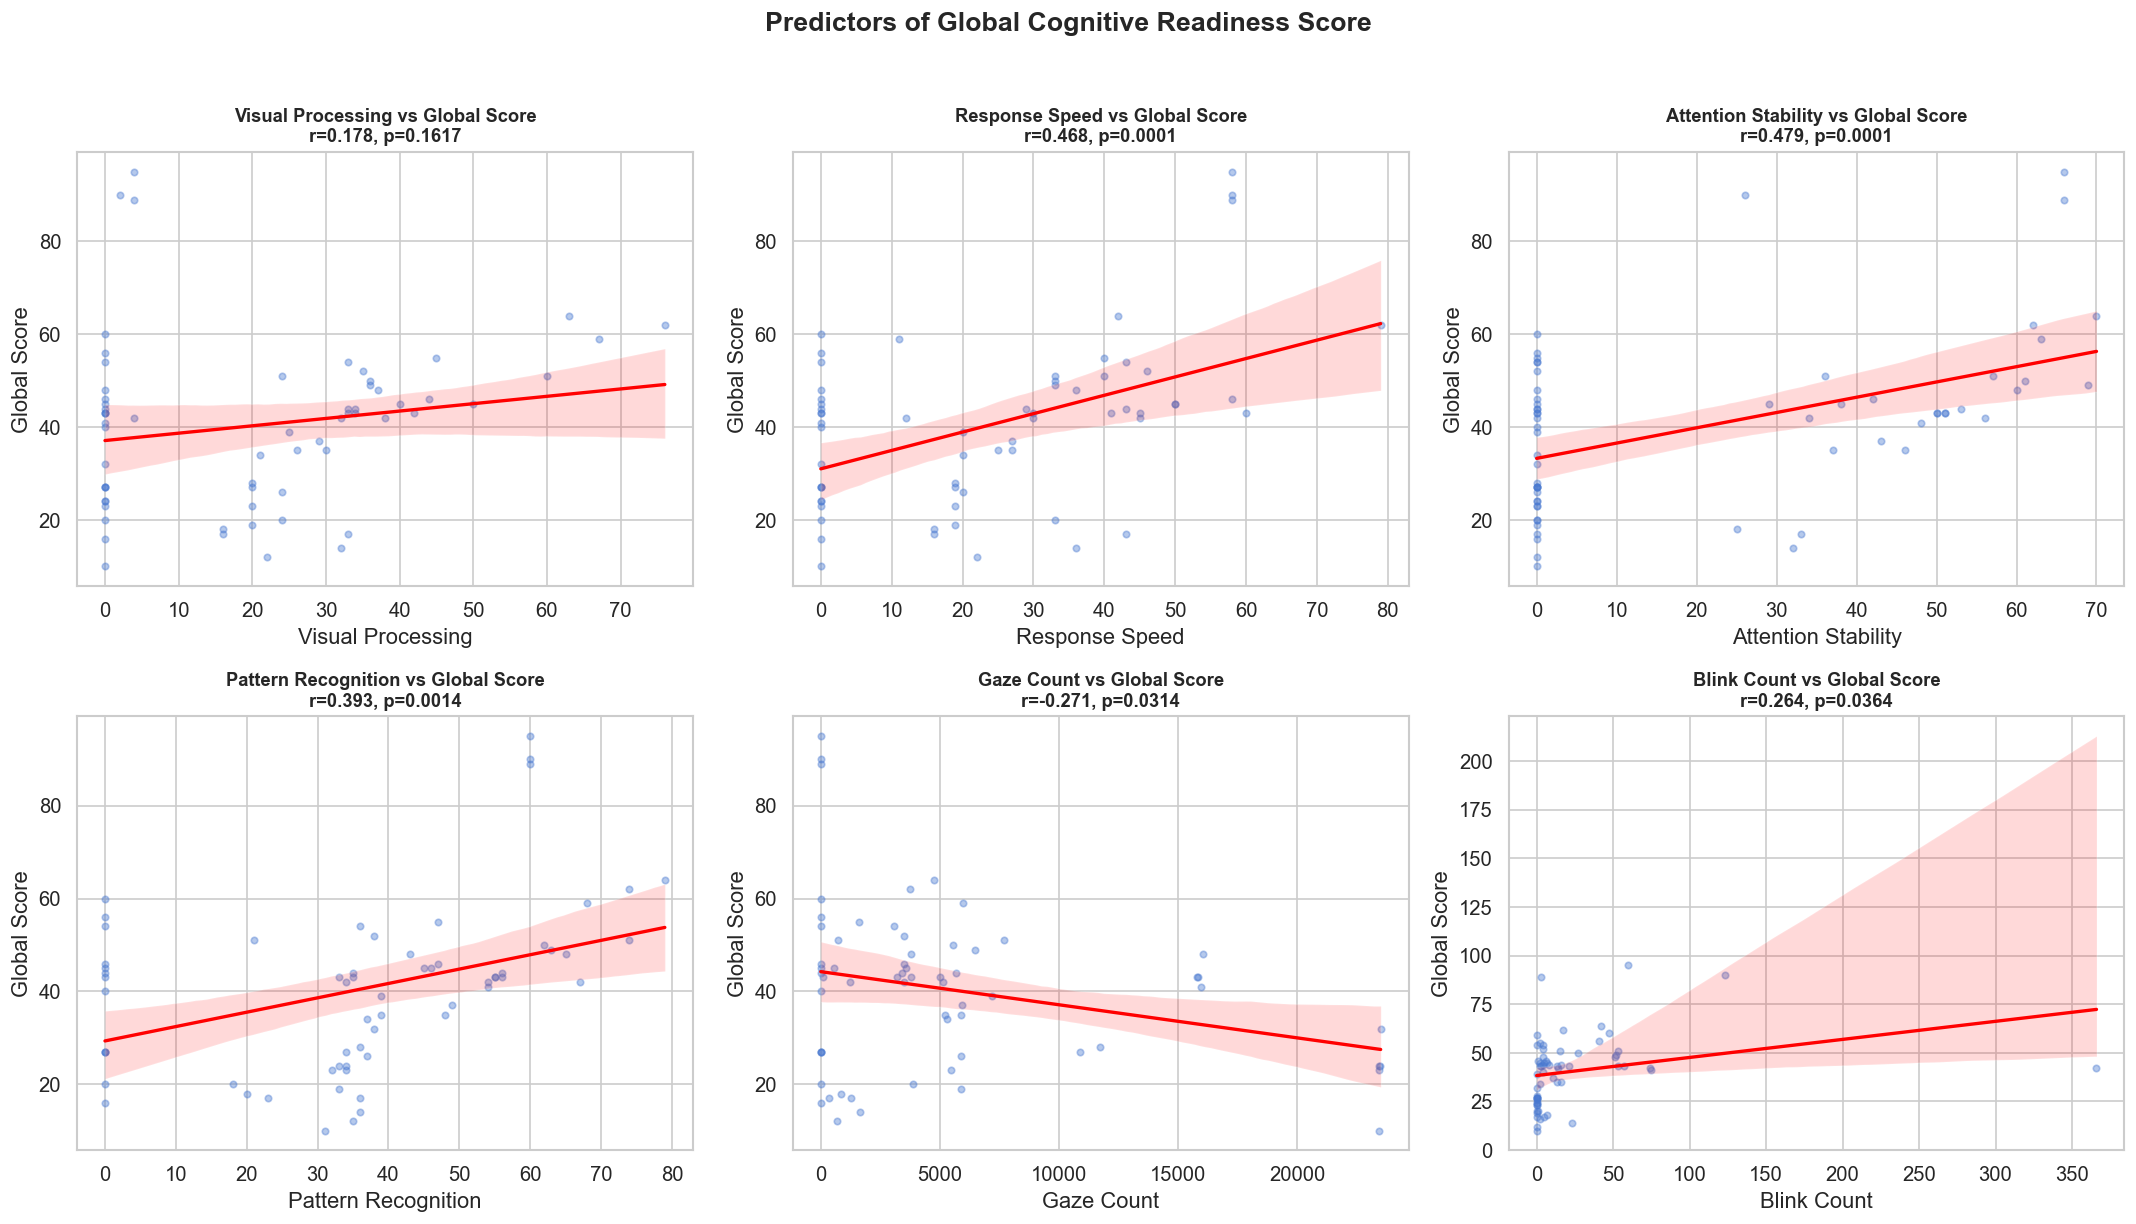

In [17]:
# --- 7b. Key Scatter Plots with Regression Lines ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

pairs = [
    ('visual_processing', 'global_score'),
    ('response_speed', 'global_score'),
    ('attention_stability', 'global_score'),
    ('pattern_recognition', 'global_score'),
    ('gaze_count', 'global_score'),
    ('blink_count', 'global_score'),
]

for ax, (x, y) in zip(axes.flat, pairs):
    valid = df[[x, y]].dropna()
    sns.regplot(data=valid, x=x, y=y, ax=ax, scatter_kws={'alpha': 0.4, 's': 15},
                line_kws={'color': 'red', 'linewidth': 2})
    r, p = pearsonr(valid[x], valid[y])
    ax.set_title(f"{x.replace('_',' ').title()} vs Global Score\nr={r:.3f}, p={p:.4f}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(x.replace('_', ' ').title())
    ax.set_ylabel('Global Score')

plt.suptitle("Predictors of Global Cognitive Readiness Score", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Between-Group Comparisons

### Rationale

Subgroup analysis evaluates whether **demographic factors** (gender, age, occupation, device used) significantly influence cognitive scores. This step is critical for:

1. **Identifying biases** — Device type (laptop vs. desktop vs. mobile) could affect eye-tracking quality
2. **Assessing fairness** — Are scores comparable across demographic groups?
3. **Guiding recommendations** — Adapting interpretation based on participant profile

### Visual Tools

- **Boxplot**: Quick comparison of medians and spreads across groups
- **Violin plot**: Combines boxplot and KDE — shows the complete distribution shape per group
- **Mean barplot**: Synthetic view of central tendencies by category

> **Important caveat:** Visual differences between groups are not necessarily **statistically significant**. Formal tests (section 9) are required to draw conclusions.

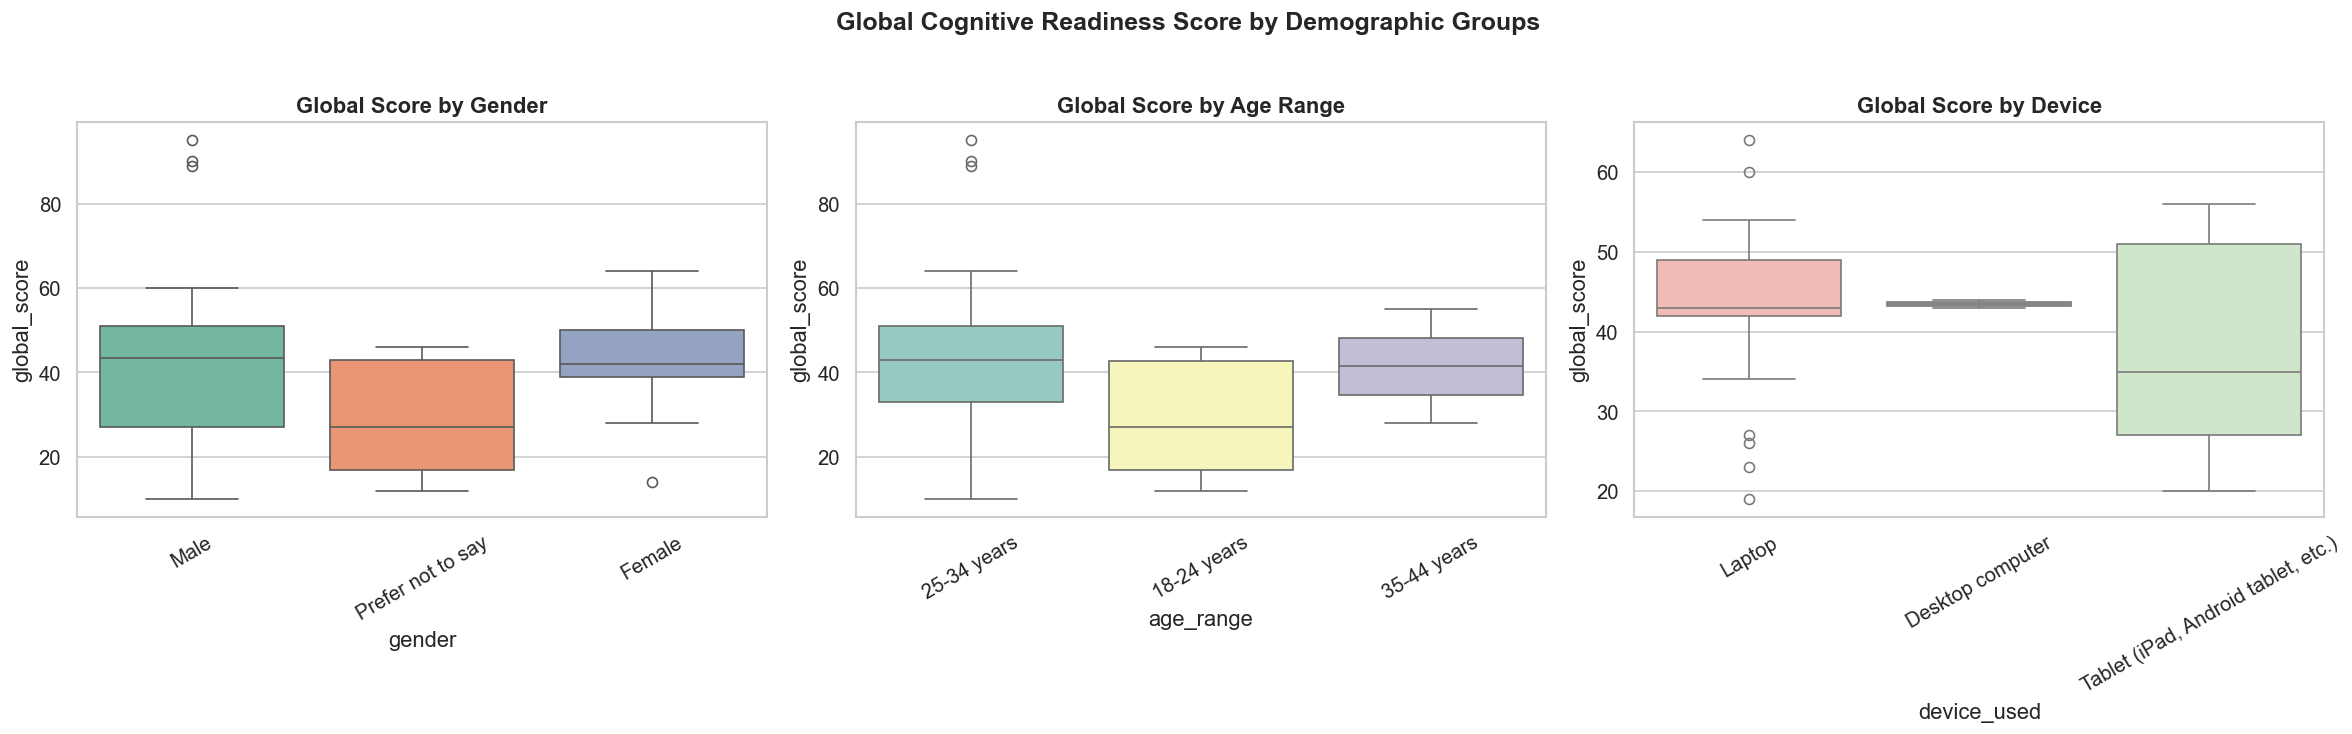

In [18]:
# --- 8a. Global Score by Gender ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# By Gender
sns.boxplot(data=df, x='gender', y='global_score', palette='Set2', ax=axes[0])
axes[0].set_title("Global Score by Gender", fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# By Age Range
sns.boxplot(data=df, x='age_range', y='global_score', palette='Set3', ax=axes[1])
axes[1].set_title("Global Score by Age Range", fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

# By Device Used
sns.boxplot(data=df, x='device_used', y='global_score', palette='Pastel1', ax=axes[2])
axes[2].set_title("Global Score by Device", fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle("Global Cognitive Readiness Score by Demographic Groups", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

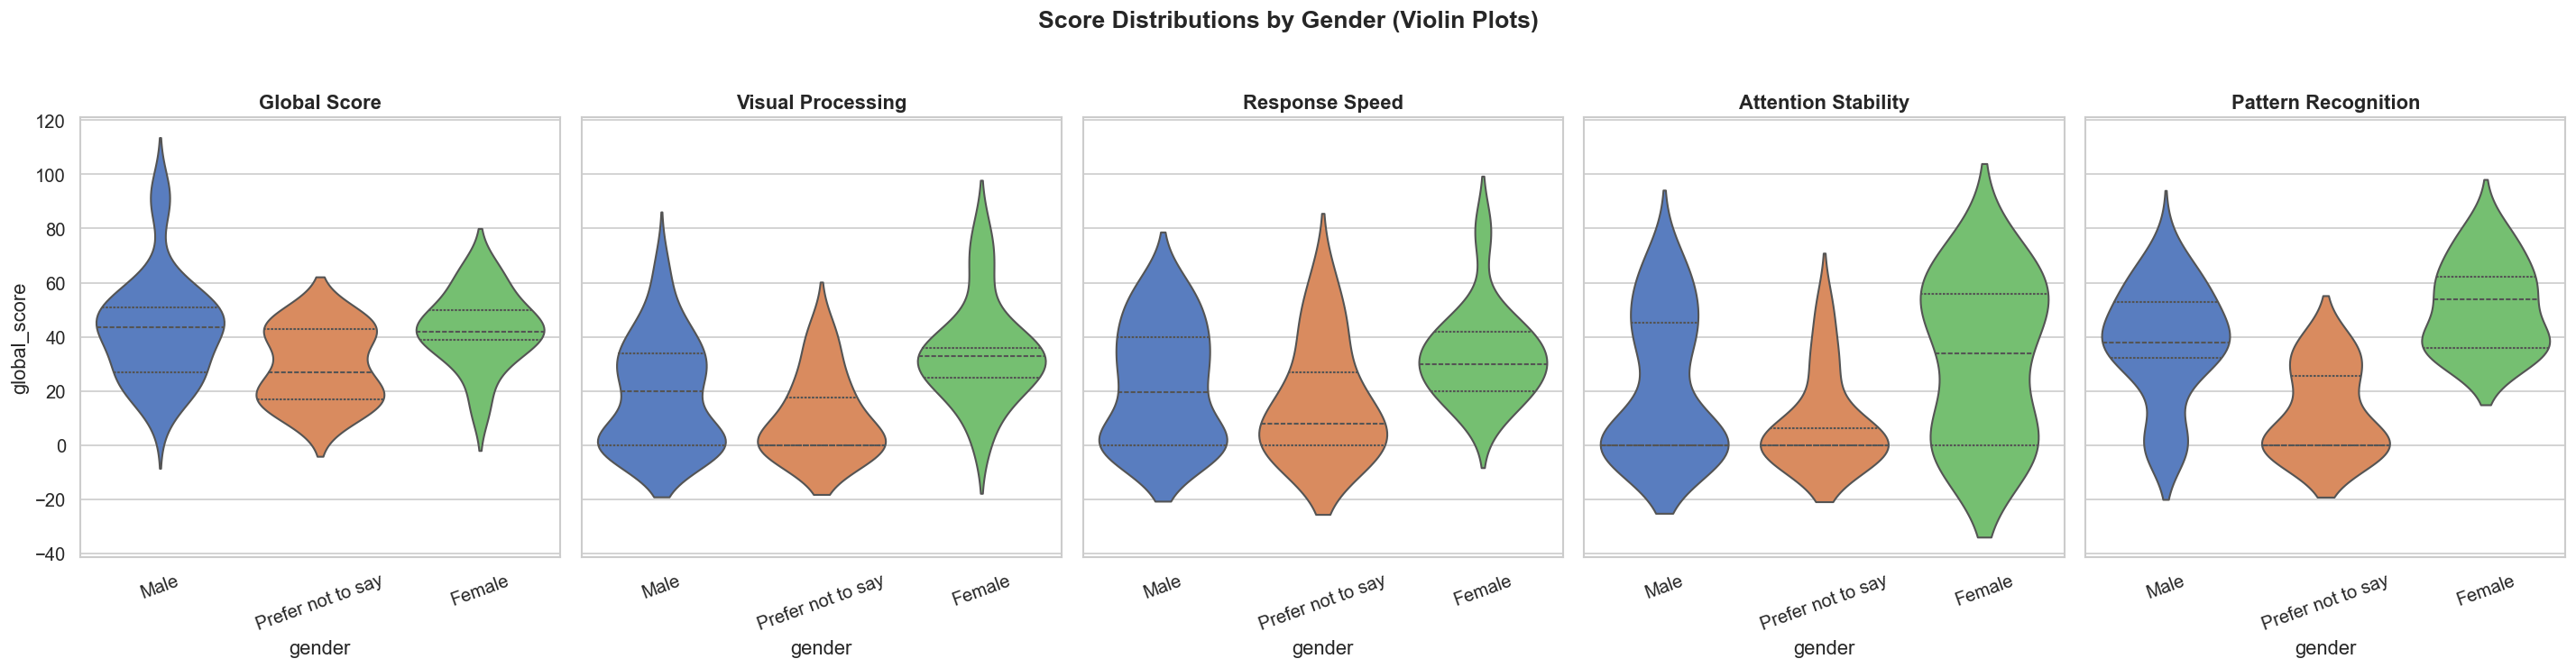

In [20]:
# --- 8b. Violin plots: All scores by Gender ---
df_gender = df[df['gender'].isin(df['gender'].value_counts().head(3).index)]

fig, axes = plt.subplots(1, 5, figsize=(24, 6), sharey=True)
for ax, col in zip(axes, SCORE_COLS):
    sns.violinplot(data=df_gender, x='gender', y=col, palette='muted', ax=ax, inner='quartile')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle("Score Distributions by Gender (Violin Plots)", fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

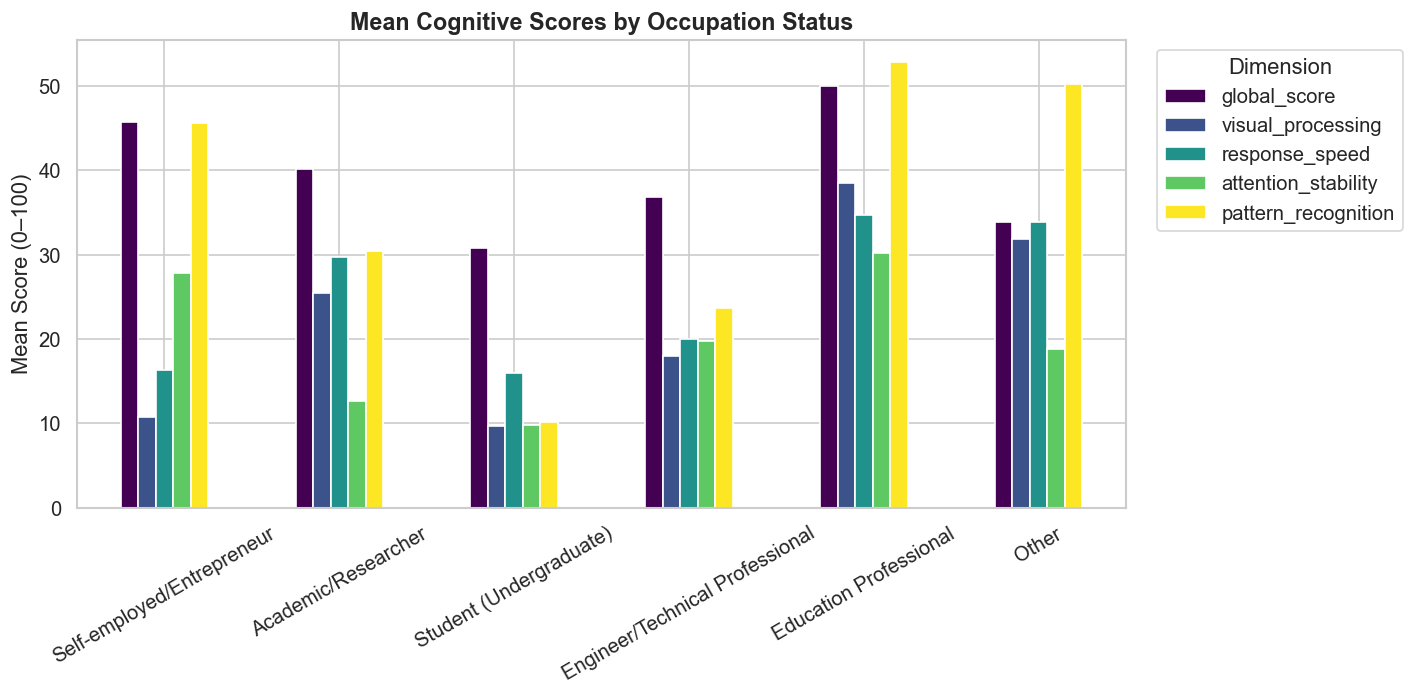

In [19]:
# --- 8c. Mean scores by Occupation Status ---
occ_means = df.groupby('occupation_status')[SCORE_COLS].mean().dropna()
occ_means = occ_means.loc[df['occupation_status'].value_counts().head(6).index]

fig, ax = plt.subplots(figsize=(12, 6))
occ_means.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white')
ax.set_title("Mean Cognitive Scores by Occupation Status", fontweight='bold', fontsize=14)
ax.set_ylabel("Mean Score (0–100)")
ax.set_xlabel("")
ax.legend(title="Dimension", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 9. Hypothesis Testing: ANOVA & Kruskal-Wallis

### 9.1. Theoretical Framework

Group comparison tests address the question: **"Are the means (or distributions) of the groups significantly different?"**

#### One-Way ANOVA

- **Hypotheses:**
  - $H_0$: $\mu_1 = \mu_2 = ... = \mu_k$ (all means are equal)
  - $H_1$: At least one mean differs
- **Assumptions:**
  1. **Independence** of observations
  2. **Normality** of distributions within each group
  3. **Homogeneity of variances** (homoscedasticity)
- **Test statistic:** $F = \frac{\text{Between-group variance}}{\text{Within-group variance}}$

#### Kruskal-Wallis (Non-Parametric Alternative)

- Non-parametric equivalent of ANOVA
- Based on **ranks** of observations
- Requires **neither normality nor homoscedasticity**
- Statistic $H$ follows approximately a $\chi^2$ distribution with $k-1$ degrees of freedom

### 9.2. Post-Hoc Tests

If the omnibus test (ANOVA or Kruskal-Wallis) is significant, it indicates that **at least one** group differs, but **does not specify which one**. **Post-hoc** tests (here Mann-Whitney U) compare groups **pairwise**.

#### Mann-Whitney U Test

- Non-parametric test for two independent samples
- $H_0$: The distributions of the two groups are identical
- Robust to non-normality and outliers

> **Multiple comparisons problem:** Each test carries an $\alpha = 5\%$ risk of false positive. With $k$ comparisons, the overall risk increases ($1 - (1-\alpha)^k$). The **Bonferroni correction** ($\alpha_{corr} = \alpha / k$) is a conservative solution.

In [21]:
# --- 9a. One-Way ANOVA / Kruskal-Wallis: Global Score by demographic groups ---

def group_test(df, group_col, value_col, min_group_size=5):
    """Run ANOVA and Kruskal-Wallis for a grouping variable."""
    groups = df.groupby(group_col)[value_col].apply(list)
    groups = {k: v for k, v in groups.items() if len(v) >= min_group_size}
    
    if len(groups) < 2:
        return None
    
    group_lists = list(groups.values())
    
    # ANOVA (parametric)
    f_stat, p_anova = f_oneway(*group_lists)
    
    # Kruskal-Wallis (non-parametric)
    h_stat, p_kruskal = kruskal(*group_lists)
    
    return {
        'Groups': list(groups.keys()),
        'N_groups': len(groups),
        'F-statistic': round(f_stat, 4),
        'ANOVA p-value': round(p_anova, 6),
        'H-statistic': round(h_stat, 4),
        'Kruskal p-value': round(p_kruskal, 6),
        'Significant (ANOVA)': 'Yes' if p_anova < 0.05 else 'No',
        'Significant (Kruskal)': 'Yes' if p_kruskal < 0.05 else 'No',
    }

print("=" * 80)
print("STATISTICAL TESTS: Global Score by Demographic Groups")
print("=" * 80)

for group_col in ['gender', 'age_range', 'occupation_status', 'device_used']:
    result = group_test(df, group_col, 'global_score')
    if result:
        print(f"\n--- {group_col.replace('_', ' ').upper()} ---")
        print(f"  Groups ({result['N_groups']}): {result['Groups']}")
        print(f"  ANOVA:          F = {result['F-statistic']}, p = {result['ANOVA p-value']}  [{result['Significant (ANOVA)']}]")
        print(f"  Kruskal-Wallis: H = {result['H-statistic']}, p = {result['Kruskal p-value']}  [{result['Significant (Kruskal)']}]")

STATISTICAL TESTS: Global Score by Demographic Groups

--- GENDER ---
  Groups (3): ['Female', 'Male', 'Prefer not to say']
  ANOVA:          F = 3.0903, p = 0.052798  [No]
  Kruskal-Wallis: H = 6.2353, p = 0.044261  [Yes]

--- AGE RANGE ---
  Groups (2): ['18-24 years', '25-34 years']
  ANOVA:          F = 8.0183, p = 0.006324  [Yes]
  Kruskal-Wallis: H = 8.0708, p = 0.004498  [Yes]

--- OCCUPATION STATUS ---
  Groups (6): ['Academic/Researcher', 'Education Professional', 'Engineer/Technical Professional', 'Other', 'Self-employed/Entrepreneur', 'Student (Undergraduate)']
  ANOVA:          F = 1.4803, p = 0.211874  [No]
  Kruskal-Wallis: H = 8.2072, p = 0.145179  [No]

--- DEVICE USED ---
  Groups (2): ['Laptop', 'Tablet (iPad, Android tablet, etc.)']
  ANOVA:          F = 0.6591, p = 0.424862  [No]
  Kruskal-Wallis: H = 0.2392, p = 0.624815  [No]


In [22]:
# --- 9b. Post-hoc: Mann-Whitney U for pairwise gender comparisons ---
from itertools import combinations

print("=== Post-hoc Pairwise Mann-Whitney U Tests (Global Score) ===\n")

for group_col in ['gender', 'age_range']:
    groups = df.groupby(group_col)['global_score'].apply(lambda x: x.dropna().values)
    groups = {k: v for k, v in groups.items() if len(v) >= 5}
    
    if len(groups) < 2:
        continue
    
    print(f"--- {group_col.replace('_', ' ').upper()} ---")
    for (g1, v1), (g2, v2) in combinations(groups.items(), 2):
        u_stat, p_val = mannwhitneyu(v1, v2, alternative='two-sided')
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"  {g1} vs {g2}: U={u_stat:.0f}, p={p_val:.6f} [{sig}]")
    print()

=== Post-hoc Pairwise Mann-Whitney U Tests (Global Score) ===

--- GENDER ---
  Female vs Male: U=252, p=0.922472 [ns]
  Female vs Prefer not to say: U=113, p=0.060085 [ns]
  Male vs Prefer not to say: U=336, p=0.014971 [*]

--- AGE RANGE ---
  18-24 years vs 25-34 years: U=164, p=0.004621 [**]



## 10. Multiple Linear Regression

### 10.1. Theoretical Model

**Multiple linear regression** (OLS — Ordinary Least Squares) models the relationship between a dependent variable $Y$ and multiple predictors $X_1, X_2, ..., X_p$:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_p X_p + \varepsilon$$

where:
- $\beta_0$: **intercept** (predicted value when all predictors = 0)
- $\beta_i$: **regression coefficient** — change in $Y$ for a one-unit increase in $X_i$, holding all other variables constant
- $\varepsilon$: **error term** — $\varepsilon \sim \mathcal{N}(0, \sigma^2)$

### 10.2. Evaluation Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **$R^2$** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained (0 to 1) |
| **Adjusted $R^2$** | Penalizes the number of predictors | Prevents overfitting |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Average error in $Y$ units |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Mean absolute error — robust |

### 10.3. Validity Conditions (Gauss-Markov Assumptions)

1. **Linearity**: the relationship between $Y$ and $X$ is linear
2. **Independence** of errors (no autocorrelation)
3. **Homoscedasticity**: the variance of residuals is constant
4. **Normality** of residuals: $\varepsilon \sim \mathcal{N}(0, \sigma^2)$
5. **No multicollinearity**: predictors are not too highly correlated with each other

### 10.4. Residual Diagnostics

The **residual plots** (section 10c) allow verification of these assumptions:
- **Residuals vs. Predicted values**: if the cloud is random and centered at 0 → homoscedasticity holds
- **Histogram of residuals**: should be approximately Gaussian
- **Q-Q Plot**: points should follow the diagonal → normality of residuals

> **Interpreting coefficients:** A positive $\beta$ means the predictor contributes positively to the global score. The relative magnitude of $\beta$ values (when variables are on the same scale) indicates the **relative importance** of each cognitive dimension.

In [23]:
# --- 10a. OLS Regression: Predicting Global Score from Sub-dimensions ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

predictors = ['visual_processing', 'response_speed', 'attention_stability', 'pattern_recognition']
target = 'global_score'

df_reg = df[predictors + [target]].dropna()
X = df_reg[predictors]
y = df_reg[target]

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print("=== OLS Multiple Linear Regression ===")
print(f"Target: {target}")
print(f"Predictors: {predictors}")
print(f"N = {len(df_reg)}")
print(f"\nR² = {r2_score(y, y_pred):.4f}")
print(f"Adjusted R² = {1 - (1 - r2_score(y, y_pred)) * (len(y) - 1) / (len(y) - len(predictors) - 1):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y, y_pred)):.2f}")
print(f"MAE = {mean_absolute_error(y, y_pred):.2f}")
print(f"\nIntercept = {model.intercept_:.4f}")
print("\nCoefficients:")
for name, coef in zip(predictors, model.coef_):
    print(f"  {name:<25} β = {coef:>8.4f}")

=== OLS Multiple Linear Regression ===
Target: global_score
Predictors: ['visual_processing', 'response_speed', 'attention_stability', 'pattern_recognition']
N = 63

R² = 0.3988
Adjusted R² = 0.3574
RMSE = 13.66
MAE = 10.77

Intercept = 28.9227

Coefficients:
  visual_processing         β =  -0.3964
  response_speed            β =   0.4815
  attention_stability       β =   0.2480
  pattern_recognition       β =   0.0796


### 10b. Coefficient Visualization

The chart below shows the **relative contribution** of each sub-dimension to the global score. Green bars indicate a positive contribution, red bars a negative contribution. A larger coefficient means a greater weight in the composite score construction.

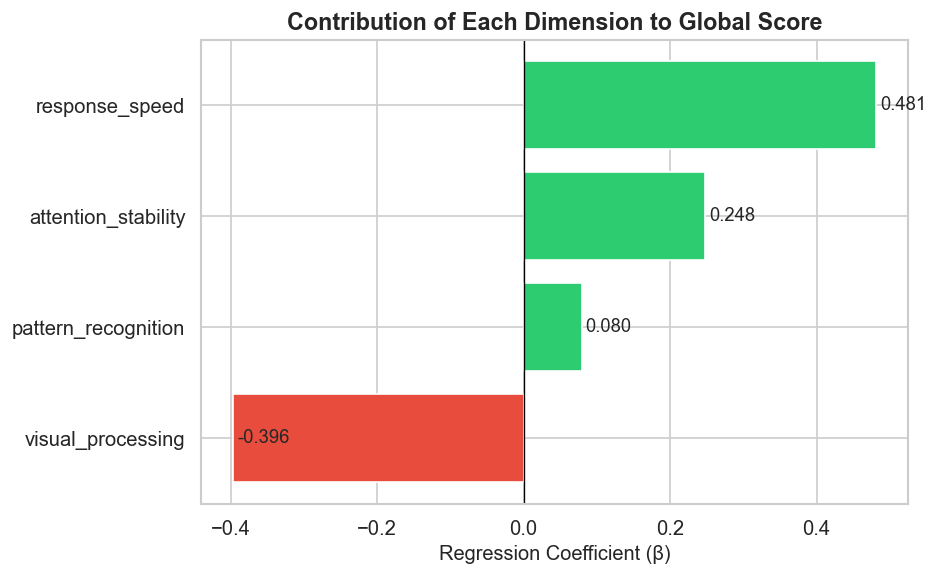

In [24]:
# --- 10b. Regression Coefficient Visualization ---
coefs = pd.DataFrame({
    'Predictor': predictors,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs['Coefficient']]
ax.barh(coefs['Predictor'], coefs['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Regression Coefficient (β)", fontsize=12)
ax.set_title("Contribution of Each Dimension to Global Score", fontsize=14, fontweight='bold')
for i, (_, row) in enumerate(coefs.iterrows()):
    ax.text(row['Coefficient'] + 0.005, i, f"{row['Coefficient']:.3f}", va='center', fontsize=11)
plt.tight_layout()
plt.show()

### 10c. Residual Diagnostics

The following three plots verify the **linear model assumptions**:

1. **Residuals vs. Predicted Values** — A funnel pattern would indicate heteroscedasticity. A random cloud validates the homoscedasticity assumption.
2. **Histogram of Residuals** — The red curve represents a theoretical normal distribution. A good fit confirms normality of errors.
3. **Q-Q Plot** (Quantile-Quantile) — Compares empirical quantiles to theoretical quantiles of a normal distribution. Points aligned on the diagonal confirm normality.

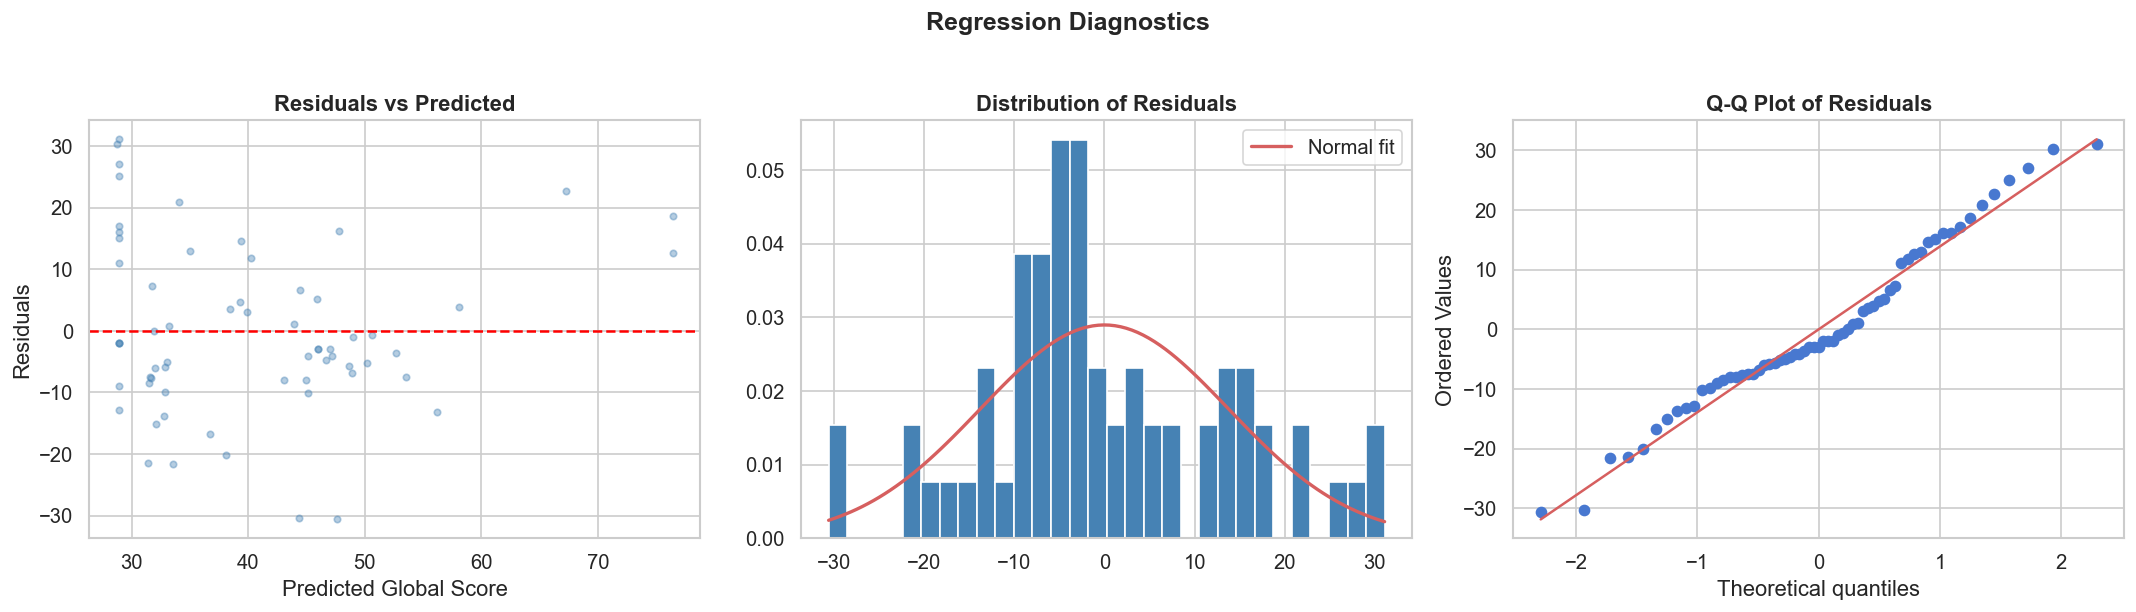

In [25]:
# --- 10c. Residuals Analysis ---
residuals = y - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.4, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted Global Score")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted", fontweight='bold')

# Histogram of residuals
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[1].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
             'r-', linewidth=2, label='Normal fit')
axes[1].set_title("Distribution of Residuals", fontweight='bold')
axes[1].legend()

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot of Residuals", fontweight='bold')

plt.suptitle("Regression Diagnostics", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Summary & Conclusions

### Methodological Overview

| Step | Method | Objective | Section |
|---|---|---|---|
| Descriptive Statistics | Mean, SD, Median, Skewness, Kurtosis | Characterize score distributions | 4 |
| Normality Tests | Shapiro-Wilk | Choose parametric vs. non-parametric tests | 5 |
| Bivariate Correlation | Pearson ($r$) and Spearman ($\rho$) | Relationships between cognitive dimensions | 6 |
| Pairplot | Scatter + KDE | Visual bivariate exploration | 7 |
| Simple Regression | OLS lines with $r$ and $p$ | Predictor-outcome relationships | 7 |
| Group Comparisons | Boxplots, Violin plots, Barplots | Demographic differences | 8 |
| Omnibus Tests | ANOVA + Kruskal-Wallis | Significance of overall group differences | 9 |
| Post-Hoc Tests | Mann-Whitney U | Pairwise contrasts | 9 |
| Multiple Regression | OLS with $R^2$, $\beta$, RMSE | Predicting the global score | 10 |
| Diagnostics | Residual plots, Q-Q plot | Validating model assumptions | 10 |

### Key Takeaways

1. **Instrument validity**: The correlation between sub-dimensions and the global score informs the **internal consistency** of the measurement system.

2. **Demographic factors**: ANOVA/Kruskal-Wallis tests identify whether gender, age, or device used significantly influence scores — a key issue of assessment **fairness**.

3. **Predictive model**: The $R^2$ from the multiple regression indicates how well the four sub-dimensions explain the global score. A high $R^2$ confirms the composite score is well-constructed.

4. **Limitations**:
   - Webcam-based eye-tracking: lower precision than professional systems (Tobii, SR Research)
   - Convenience sample (non-random): limits generalizability
   - Cross-sectional design: causality cannot be established
   - Potential confounders: lighting, position, fatigue, webcam quality

### Future Directions

- **Exploratory Factor Analysis (EFA)** to validate the dimensional structure
- **Mixed-effects models** to account for repeated measures
- **Machine Learning** (Random Forest, XGBoost) for non-linear prediction
- **Longitudinal analysis** to study cognitive readiness changes over time

---

*By Safae Meftah Menani — March 2026*